In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\waste_risk_dataset.csv")

In [7]:
print("Dataset shape:", df.shape)

Dataset shape: (5000, 10)


In [9]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['rainfall_intensity', 'collection_interval', 'public_awareness', 'waste_generation_rate', 'num_households', 'num_collectors', 'average_blockage', 'total_waste', 'flood_risk_score', 'risk_category']


In [11]:
print("\nRisk category counts:")
print(df["risk_category"].value_counts())


Risk category counts:
risk_category
Low       2878
Medium    1962
High       160
Name: count, dtype: int64


In [13]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
rainfall_intensity       0
collection_interval      0
public_awareness         0
waste_generation_rate    0
num_households           0
num_collectors           0
average_blockage         0
total_waste              0
flood_risk_score         0
risk_category            0
dtype: int64


In [15]:
df.head()

,rainfall_intensity,collection_interval,public_awareness,waste_generation_rate,num_households,num_collectors,average_blockage,total_waste,flood_risk_score,risk_category
0,34,2,11,1.800091,29,3,15.317532,629.766390,16.724777,Low
1,63,7,56,4.544886,38,2,19.034551,1064.718155,32.395060,Medium
2,23,7,62,6.086398,51,2,25.713616,1798.242176,12.748479,Low
3,56,6,100,8.662766,95,2,0.000000,0.000000,22.400000,Low
4,55,1,76,7.159176,38,3,10.468235,595.921980,25.454517,Low


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [21]:
features = [
    "rainfall_intensity",
    "collection_interval",
    "public_awareness",
    "waste_generation_rate",
    "num_households",
    "num_collectors"
]

In [23]:
X = df[features]
y = df["risk_category"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [29]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [31]:
print("Training scenarios:", len(X_train))

Training scenarios: 4000


In [33]:
print("Testing scenarios:", len(X_test))

Testing scenarios: 1000


In [35]:
print("\nModel training complete!")


Model training complete!


In [37]:
y_pred = model.predict(X_test)

In [39]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.969


In [41]:
print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    labels=["High", "Low", "Medium"],
    zero_division=0
))


Classification report:
              precision    recall  f1-score   support

        High       1.00      0.72      0.84        32
         Low       0.98      0.98      0.98       576
      Medium       0.95      0.97      0.96       392

    accuracy                           0.97      1000
   macro avg       0.98      0.89      0.93      1000
weighted avg       0.97      0.97      0.97      1000



In [43]:
print("Confusion matrix:")
print(confusion_matrix(
    y_test,
    y_pred,
    labels=["High", "Low", "Medium"]
))
print("\nConfusion matrix label order: High, Low, Medium")

Confusion matrix:
[[ 23   0   9]
 [  0 567   9]
 [  0  13 379]]

Confusion matrix label order: High, Low, Medium


Random Forest feature importance:
rainfall_intensity       0.6345
num_households           0.1666
public_awareness         0.1180
waste_generation_rate    0.0511
num_collectors           0.0164
collection_interval      0.0134
dtype: float64


<Axes: title={'center': 'Feature Importance for Simulated Flood-Risk Classification'}, xlabel='Importance'>

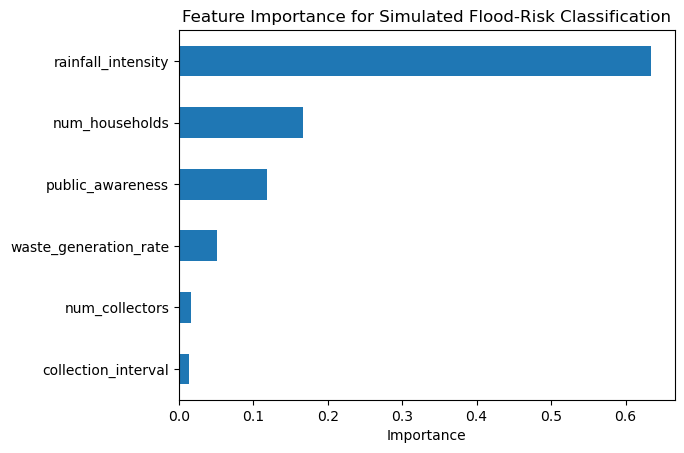

In [45]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Random Forest feature importance:")
print(importance.round(4))

importance.sort_values().plot(
    kind="barh",
    title="Feature Importance for Simulated Flood-Risk Classification",
    xlabel="Importance"
)

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [49]:
print("BASELINE MODEL")
print("Accuracy:", round(accuracy_score(y_test, model.predict(X_test)), 3))
print(classification_report(y_test, model.predict(X_test), zero_division=0))

BASELINE MODEL
Accuracy: 0.969
              precision    recall  f1-score   support

        High       1.00      0.72      0.84        32
         Low       0.98      0.98      0.98       576
      Medium       0.95      0.97      0.96       392

    accuracy                           0.97      1000
   macro avg       0.98      0.89      0.93      1000
weighted avg       0.97      0.97      0.97      1000



In [51]:
improved_model = RandomForestClassifier(
    n_estimators=300,
    class_weight={
        "High": 4.0,
        "Medium": 1.0,
        "Low": 1.0
    },
    random_state=42,
    n_jobs=-1
)

In [53]:
improved_model.fit(X_train, y_train)
improved_pred = improved_model.predict(X_test)

print("\nHIGH-WEIGHT MODEL")


HIGH-WEIGHT MODEL


In [55]:
print("Accuracy:", round(accuracy_score(y_test, improved_pred), 3))
print(classification_report(
    y_test,
    improved_pred,
    labels=["High", "Low", "Medium"],
    zero_division=0
))

Accuracy: 0.966
              precision    recall  f1-score   support

        High       1.00      0.66      0.79        32
         Low       0.98      0.98      0.98       576
      Medium       0.95      0.97      0.96       392

    accuracy                           0.97      1000
   macro avg       0.98      0.87      0.91      1000
weighted avg       0.97      0.97      0.97      1000



In [57]:
print("Confusion matrix (High, Low, Medium):")
print(confusion_matrix(
    y_test,
    improved_pred,
    labels=["High", "Low", "Medium"]
))

Confusion matrix (High, Low, Medium):
[[ 21   0  11]
 [  0 566  10]
 [  0  13 379]]


In [59]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [61]:
proba = model.predict_proba(X_test)
classes = list(model.classes_)
high_index = classes.index("High")

In [63]:
baseline_pred = model.predict(X_test)

In [65]:
threshold = 0.20

In [67]:
adjusted_pred = []
for i, probabilities in enumerate(proba):
    if probabilities[high_index] >= threshold:
        adjusted_pred.append("High")
    else:
        # If not High, use the highest-probability non-High class
        non_high_indices = [
            j for j, label in enumerate(classes) if label != "High"
        ]
        best_index = max(
            non_high_indices,
            key=lambda j: probabilities[j]
        )
        adjusted_pred.append(classes[best_index])

print("Baseline accuracy:", round(
    accuracy_score(y_test, baseline_pred), 3
))

Baseline accuracy: 0.969


In [69]:
print("Adjusted-threshold accuracy:", round(
    accuracy_score(y_test, adjusted_pred), 3
))

Adjusted-threshold accuracy: 0.963


In [71]:
print("\nAdjusted-threshold report:")
print(classification_report(
    y_test, adjusted_pred,
    labels=["High", "Low", "Medium"],
    zero_division=0
))


Adjusted-threshold report:
              precision    recall  f1-score   support

        High       0.70      0.94      0.80        32
         Low       0.98      0.98      0.98       576
      Medium       0.97      0.93      0.95       392

    accuracy                           0.96      1000
   macro avg       0.88      0.95      0.91      1000
weighted avg       0.97      0.96      0.96      1000



In [73]:
print("Confusion matrix (High, Low, Medium):")
print(confusion_matrix(
    y_test, adjusted_pred,
    labels=["High", "Low", "Medium"]
))

Confusion matrix (High, Low, Medium):
[[ 30   0   2]
 [  0 567   9]
 [ 13  13 366]]


In [75]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import joblib

In [77]:
baseline_pred = model.predict(X_test)

In [79]:
report = classification_report(
    y_test,
    baseline_pred,
    labels=["Low", "Medium", "High"],
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report).transpose().to_csv(
    "baseline_model_report.csv"
)

In [81]:
cm = confusion_matrix(
    y_test,
    baseline_pred,
    labels=["High", "Low", "Medium"]
)

pd.DataFrame(
    cm,
    index=["Actual High", "Actual Low", "Actual Medium"],
    columns=["Predicted High", "Predicted Low", "Predicted Medium"]
).to_csv("baseline_confusion_matrix.csv")

In [83]:
joblib.dump(model, "baseline_flood_risk_model.joblib")

['baseline_flood_risk_model.joblib']

In [85]:
print("Baseline accuracy:", round(
    accuracy_score(y_test, baseline_pred), 3
))

Baseline accuracy: 0.969


In [87]:
print("Saved report, confusion matrix, and baseline model.")

Saved report, confusion matrix, and baseline model.


In [91]:
predictions = model.predict(X_test)

report = classification_report(
    y_test, predictions, output_dict=True, zero_division=0
)
pd.DataFrame(report).transpose().to_csv("baseline_model_report.csv")

cm = confusion_matrix(
    y_test, predictions,
    labels=["High", "Low", "Medium"]
)
pd.DataFrame(
    cm,
    index=["Actual High", "Actual Low", "Actual Medium"],
    columns=["Predicted High", "Predicted Low", "Predicted Medium"]
).to_csv("baseline_confusion_matrix.csv")

print("Model and evaluation files saved successfully.")

Model and evaluation files saved successfully.


In [93]:
import joblib

joblib.dump(model, "baseline_flood_risk_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [95]:
import os

print("Your files are saved in:")
print(os.getcwd())

print("\nModel file exists:", os.path.exists("baseline_flood_risk_model.joblib"))

Your files are saved in:
C:\Users\User

Model file exists: True


In [97]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(X_test)

pd.DataFrame(
    classification_report(
        y_test, predictions, output_dict=True, zero_division=0
    )
).to_csv("baseline_model_report.csv")

pd.DataFrame(
    confusion_matrix(
        y_test, predictions,
        labels=["High", "Low", "Medium"]
    ),
    index=["Actual High", "Actual Low", "Actual Medium"],
    columns=["Predicted High", "Predicted Low", "Predicted Medium"]
).to_csv("baseline_confusion_matrix.csv")

print("Evaluation files saved!")

Evaluation files saved!


In [99]:
import os

print("Your files are saved in:")
print(os.getcwd())

print("\nModel file exists:", os.path.exists("baseline_model_report.csv"))

Your files are saved in:
C:\Users\User

Model file exists: True
